# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [1]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [2]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [3]:
now = Time.now()
now_ist = now.to_datetime(timezone=IITK_TIMEZONE)
print("ISO UTC: ", now)
print("IIT Kanpur civil clock:", now_ist) 

ISO UTC:  2026-09-06 18:21:36.293831
IIT Kanpur civil clock: 2026-09-06 23:51:36.293831+05:30


Time.now() extrcats the current time of the system and returns a time object in UTC units, two separate calls to Time.now() would necessarily imply that they are called at separate times in the code with some time difference $\Delta t$, this would extract the current time corresponding to those two separate calls, differing by $\Delta t$ amount.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [4]:
height = 2396*u.m
wavelength = 600*u.nm
uncertainty = 5*u.mas
cadence = 10*u.min
freq = 1.4*u.GHz

#convirsion
height_km = height.to(u.km)
wavelength_cm = wavelength.to(u.cm, equivalencies=u.spectral())
uncertainty_arcsec = uncertainty.to(u.arcsec)
cadence_hour = cadence.to(u.hr)
freq_THz = freq.to(u.THz, equivalencies=u.spectral())


#printing
print("=====================================")
print("       ORIGINAL VALUES               ")
print("=====================================")
print(f"GTC Height = {height}")
print(f"Wavelength = {wavelength}")
print(f"Uncertainty = {uncertainty}")
print(f"Cadence = {cadence}")
print(f"Frequency = {freq}")
print("")
print("=====================================")
print("       CONVERTED VALUES              ")
print("=====================================")
print(f"GTC Height = {height_km}")
print(f"Wavelength = {wavelength_cm}")
print(f"Uncertainty = {uncertainty_arcsec}")
print(f"Cadence = {cadence_hour}")
print(f"Frequency = {freq_THz}")







       ORIGINAL VALUES               
GTC Height = 2396.0 m
Wavelength = 600.0 nm
Uncertainty = 5.0 mas
Cadence = 10.0 min
Frequency = 1.4 GHz

       CONVERTED VALUES              
GTC Height = 2.396 km
Wavelength = 6.000000000000001e-05 cm
Uncertainty = 0.005 arcsec
Cadence = 0.16666666666666666 h
Frequency = 0.0014 THz


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [5]:
planning_start = Time(START_UTC, scale='utc')
t_jd = planning_start.jd
t_mjd = planning_start.mjd
t_civil = planning_start.to_datetime(timezone=IITK_TIMEZONE)

print("UTC Time = ", planning_start)
print("Julian Date = ", t_jd)
print("Modified Julian Date", t_mjd)
print("IIT Kanpur time", t_civil)



UTC Time =  2026-08-30T12:00:00.000
Julian Date =  2461283.0
Modified Julian Date 61282.5
IIT Kanpur time 2026-08-30 17:30:00+05:30


In [6]:
#adding 2.25 hour with planning_start
t_new = planning_start + 2.25*u.hr
t_new_ist = t_new.to_datetime(timezone=IITK_TIMEZONE)
print(t_new.utc)
print(f"{t_new_ist} IST")

2026-08-30T14:15:00.000
2026-08-30 19:45:00+05:30 IST


In [7]:
re_converted = Time(t_new_ist)

diff = np.abs(t_new - re_converted)
print(f"Difference = {diff.to(u.us)}")

Difference = 0.0 us


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [8]:
frb_ra = Angle(FRB_RA_J2000, unit=u.hourangle)
frb_dec = Angle(FRB_DEC_J2000, unit=u.deg)

frb_icrs = SkyCoord(ra=frb_ra, dec=frb_dec, frame='icrs')

print(f"RA in degrees: {frb_icrs.ra.deg}")
print(f"DEC in degrees: {frb_icrs.dec.deg}")

print(f"RA in sexagesimal {frb_icrs.ra.to_string(unit=u.hourangle, sep = ':', pad=True)}")
print(f"DEC in sexagesimal {frb_icrs.dec.to_string(unit=u.deg, sep=':', pad = True, alwayssign=True)}")

RA in degrees: 347.27041208333327
DEC in degrees: 48.70664105555556
RA in sexagesimal 23:09:04.8989
DEC in sexagesimal +48:42:23.9078


In [9]:
#computing differences
ra_diff = np.abs(frb_icrs.ra.deg - 347.2704120833)
dec_diff = np.abs(frb_icrs.dec.deg - 48.7066410556)

print(f"Difference in RA: {ra_diff*u.deg}")
print(f"Difference in DEC: {dec_diff*u.deg}")

Difference in RA: 3.325340003357269e-11 deg
Difference in DEC: 4.4444448121794267e-11 deg


It is convinient to take RA in hours in order to tie it to the rotation of the earth and hour angle, for example it becomes intuitive to predict meridian transit times if we take RA in hours, whereas DEC defines the angle above and below the celestial equator. Also taking different units help in distinguishing between the two coordinates. 

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [10]:
#converting icrs to galactic
frb_galactic = frb_icrs.galactic
print("l: ", (frb_galactic.l.deg)*u.deg)
print("b: ", (frb_galactic.b.deg)*u.deg)


l:  106.06496077332801 deg
b:  -10.784176285402493 deg


In [11]:
#re converting galactic to icrs
icrs_back = frb_galactic.icrs

#computing  the separation
sep = frb_icrs.separation(icrs_back)

print("Round-trip separation:", sep.to_value(u.microarcsecond),"microarcsec")

Round-trip separation: 0.0003107329036068562 microarcsec


### Reason for finite separation

Computers hava a finite precision, all of the calculations performed internally are done using floating point numbers that are trunkated after a finite number of decimal placed, introducing roundoff errors, as a result we do not get back the exact number back, we get back a highly accurate approximation

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [12]:
frb_ecliptic = frb_icrs.transform_to(BarycentricTrueEcliptic(equinox='J2000'))

print(f"Ecliptic longitude λ = {(frb_ecliptic.lon.deg)*u.deg}")
print(f"Ecliptic latitude  β = {(frb_ecliptic.lat.deg)*u.deg}")

Ecliptic longitude λ = 14.411187650340095 deg
Ecliptic latitude  β = 48.34695843744783 deg


In [13]:
#re converting to icrs
eclpt_icrs = frb_ecliptic.icrs
sep2 = eclpt_icrs.separation(frb_icrs)

print("Round-trip separation:", sep2.to_value(u.microarcsecond),"microarcsec")

Round-trip separation: 0.0 microarcsec


The ecliptic plane is the plane of Earth's orbit around the Sun, the value of $\beta$ represents the angular altitude of any celestial object above or below the ecliptic plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [14]:
earlier_position = SkyCoord(ra='23h09m04.9s', dec='+48d42m25.4s', frame='icrs')

del1 = earlier_position.dec.radian
del2 = frb_icrs.dec.radian

alph1 = earlier_position.ra.radian
alph2 = frb_icrs.ra.radian

cos_theta = np.sin(del1)*np.sin(del2) + np.cos(del1)*np.cos(del2)*np.cos(alph2 - alph1)

cos_theta = np.clip(cos_theta, -1, 1)
ang_sep = np.arccos(cos_theta)
print(f"Angular separation = {(ang_sep*u.radian).to_value(u.arcsec)} arcsec")
print(f"Angular separation = {(ang_sep*u.radian).to_value(u.mas)} mas")


Angular separation = 1.4922374490540065 arcsec
Angular separation = 1492.2374490540062 mas


In [15]:
#separation
sep3 = frb_icrs.separation(earlier_position)

new_arcsec = (ang_sep * u.radian).to_value(u.arcsec)
icrs_arcsec = sep3.to_value(u.arcsec)

diff2 = abs(new_arcsec - icrs_arcsec)
print("separation:", diff2,"microarcsec")

separation: 2.277149442564408e-06 microarcsec


Therefore, the difference is within 2.27 micro arcsecond

# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [16]:
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)

print("Longitude:", gtc_location.lon.to_value(u.deg), "deg")
print("Latitude:", gtc_location.lat.to_value(u.deg), "deg")
print("Height:", gtc_location.height.to_value(u.m), "m")

Longitude: -17.88900000000001 deg
Latitude: 28.758 deg
Height: 2395.9999999997463 m


### Meaning of negative longitude

Longitude is defined relative to Greenwich meridian, the negative longitude means the source is in the west of Greenwich

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [17]:
t = Time("2026-08-31T00:00:00Z", scale="utc")

# Apparent Local Sidereal Time at GTC
lst = t.sidereal_time(kind="apparent",longitude=gtc_location.lon)
alph = frb_icrs.ra

#hour angle
H = (lst - alph).wrap_at(12*u.hourangle)

# IIT Kanpur time
t_ist = t.to_datetime(timezone=IITK_TIMEZONE)

print("UTC:", t.iso)
print("IIT Kanpur time:", t_ist)
print("LST:", lst.to_string(unit=u.hourangle, sep=":", pad=True))
print("Hour angle:", H.to_string(unit=u.hourangle, sep=":", pad=True))

UTC: 2026-08-31 00:00:00.000
IIT Kanpur time: 2026-08-31 05:30:00+05:30
LST: 21:25:12.29974213
Hour angle: -01:43:52.59915787


The target has a negative hourangle, therefore we can say that the target is to the east of meridian.

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [18]:
#lst and hour angle of 145 samples
lst_arr = times.sidereal_time(kind="apparent", longitude=gtc_location.lon)
ha_arr = (lst_arr - frb_icrs.ra).wrap_at(12*u.hourangle)

#index of closest ha
idx = np.argmin(np.abs(ha_arr))


print("Sample index:", idx)
print("UTC:", times[idx].iso)
print("IIT Kanpur time:", times[idx].to_datetime(timezone=IITK_TIMEZONE))
print("LST:", lst_arr[idx].to_string(unit=u.hourangle, sep=":", pad=True))
print("Hour angle:", ha_arr[idx].to_string(unit=u.hourangle, sep=":", pad=True))

Sample index: 82
UTC: 2026-08-31 01:40:00.000
IIT Kanpur time: 2026-08-31 07:10:00+05:30
LST: 23:05:28.72666468
Hour angle: -00:03:36.17223532


To find the exact transit time we need the exact time where HA is 0. However, we are picking up the HA that is closest to 0 instead of HA = 0, because we have sampled observations with a finite interval. Hence we would not get the exact time of transit. The actual transit may happen between any two successive observation.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [19]:
h_transit = (90 - np.abs(GTC_LATITUDE_DEG - frb_icrs.dec.deg))*u.deg
z = (90*u.deg - h_transit)

print('h_transit = ', h_transit)
print("z = ", z)

h_transit =  70.05135894444444 deg
z =  19.948641055555555 deg


In [20]:
#AltAz frame
altaz_frame = AltAz(obstime=times, location=gtc_location, pressure=0 * u.hPa)
frb_altaz = frb_icrs.transform_to(altaz_frame)

max_idx = np.argmax(frb_altaz.alt)

max_altitude = frb_altaz.alt[max_idx]
max_zenith_distance = 90 * u.deg - max_altitude

print("Maximum sampled altitude:", max_altitude)
print("Maximum-altitude zenith distance:", max_zenith_distance)

Maximum sampled altitude: 69d53m02.10725682s
Maximum-altitude zenith distance: 20d06m57.89274318s


In [21]:
#comparison
alt_difference = abs(h_transit - max_altitude)
z_difference = abs(z - max_zenith_distance)

print("Altitude difference:", alt_difference.to(u.arcsec))
print("Zenith-distance difference:", z_difference.to(u.arcsec))

Altitude difference: 602.785 arcsec
Zenith-distance difference: 602.785 arcsec


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [22]:
before_idx = idx - 12
after_idx = idx + 12

indices = [before_idx, idx, after_idx]

phi = gtc_location.lat.radian
delta = frb_icrs.dec.radian

for i in indices:

    H = ha_arr[i].radian

    sin_h = (np.sin(phi) * np.sin(delta)+ np.cos(phi) * np.cos(delta) * np.cos(H))

    sin_h = np.clip(sin_h, -1, 1)

    h_manual = np.arcsin(sin_h) * u.radian

    h_astropy = frb_altaz.alt[i]

    difference = h_manual - h_astropy

    print("\nSample index:", i)
    print("UTC:", times[i].iso)
    print("IST:", times[i].to_datetime(timezone=IITK_TIMEZONE))
    print("Hour angle:", ha_arr[i].to_string(unit=u.hourangle, sep=":", pad=True))
    print("Calculated altitude:", h_manual.to_value(u.deg), "deg")
    print("Astropy altitude:", h_astropy.to_value(u.deg), "deg")
    print("Difference:", difference.to_value(u.arcsec), "arcsec")


Sample index: 70
UTC: 2026-08-30 23:40:00.000
IST: 2026-08-31 05:10:00+05:30
Hour angle: -02:03:55.88454043
Calculated altitude: 59.03216935573673 deg
Astropy altitude: 58.78178852683166 deg
Difference: 901.3709840582368 arcsec

Sample index: 82
UTC: 2026-08-31 01:40:00.000
IST: 2026-08-31 07:10:00+05:30
Hour angle: -00:03:36.17223532
Calculated altitude: 70.03935763656996 deg
Astropy altitude: 69.88391868244928 deg
Difference: 559.5802348344678 arcsec

Sample index: 94
UTC: 2026-08-31 03:40:00.000
IST: 2026-08-31 09:10:00+05:30
Hour angle: 01:56:43.54008267
Calculated altitude: 60.06282788493587 deg
Astropy altitude: 60.16239207420843 deg
Difference: -358.43108138120635 arcsec


### Physical Pattern
The source hour angle approaches 0 before transit and starts increasing after transit, implying that the source rises, reaches its maximum altitude and then starts setting after meridian transit.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [23]:
h_min = 20 * u.deg
hmin = h_min.to_value(u.radian)

cos_H0 = (np.sin(hmin) - np.sin(phi) * np.sin(delta)) / (np.cos(phi) * np.cos(delta))

cos_H0 = np.clip(cos_H0, -1, 1)

H0 = np.arccos(cos_H0) * u.radian
H0_hours = H0.to_value(u.hourangle)

print("H0 =", H0.to_value(u.deg), "degrees")
print("H0 =", H0_hours, "sidereal hours")

H0 = 91.92747700350239 degrees
H0 = 6.12849846690016 sidereal hours


In [24]:
#source above altitude limit
total_hours = 2 * H0.to_value(u.hourangle)

print(f"Total interval above 20 deg = {total_hours} sidereal hours")

Total interval above 20 deg = 12.25699693380032 sidereal hours


In [25]:
# Grid comparison
above_limit = frb_altaz.alt > h_min
n_above = np.count_nonzero(above_limit)

print("Grid samples above 20 deg:", n_above)

sample_interval = times[1] - times[0]

print("Sampled interval represented by these samples:", (n_above * sample_interval).to_value(u.hour), "hours")

Grid samples above 20 deg: 74
Sampled interval represented by these samples: 12.33333333333329 hours


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [26]:
#finite range
target_airmass = np.asarray(frb_altaz.secz, dtype=float)

invalid = ((frb_altaz.alt <= 0 * u.deg)| ~np.isfinite(target_airmass)| (target_airmass < 1))

target_airmass[invalid] = np.nan

print(f"Airmass range: {np.nanmin(target_airmass)} to {np.nanmax(target_airmass)}")

Airmass range: 1.0649652673937744 to 55.3481874523115


In [27]:
#best airmass
best_idx = np.nanargmin(target_airmass)
best_airmass = target_airmass[best_idx]

print("Best airmass:", best_airmass)
print("UTC:", times[best_idx].iso)
print("IST:", times[best_idx].to_datetime(timezone=IITK_TIMEZONE))

Best airmass: 1.0649652673937744
UTC: 2026-08-31 01:40:00.000
IST: 2026-08-31 07:10:00+05:30


In [28]:
#number of samples 
good_airmass = ((target_airmass >= 1)& (target_airmass <= 2.5))

print("Samples with 1 <= X <= 2.5:", np.count_nonzero(good_airmass))

Samples with 1 <= X <= 2.5: 68


### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [35]:
#sun and moon positions
sun = get_sun(times)
moon = get_body("moon", times)

altaz_frame = AltAz(obstime=times, location=gtc_location, pressure=0 * u.hPa)

#sun and moon altitudes
sun_altaz = sun.transform_to(altaz_frame)
moon_altaz = moon.transform_to(altaz_frame)
sun_altitude = sun_altaz.alt
moon_altitude = moon_altaz.alt

#moon airmass
moon_airmass = np.asarray(moon_altaz.secz, dtype=float)

invalid = ((moon_altaz.alt <= 0 * u.deg)| ~np.isfinite(moon_airmass)|(moon_airmass < 1)| (moon_airmass > 3))

moon_airmass[invalid] = np.nan

#moon target separation
moon_target_sep = moon.separation(frb_icrs)

elongation = sun.separation(moon)

epsilon = elongation.to_value(u.rad)

illuminated_fraction = (1 - np.cos(epsilon))/2

#classification 

unknown = ( ~np.isfinite(moon_altitude)| ~np.isfinite(moon_target_sep)| ~np.isfinite(illuminated_fraction))

labels = np.full(len(times), "Gray", dtype=object)

labels[unknown] = "Unknown"

finite = (np.isfinite(moon_altitude) & np.isfinite(moon_target_sep) & np.isfinite(illuminated_fraction))

labels[finite] = "Gray"

bright = finite & (
    ((illuminated_fraction >= 0.70) & (moon_altitude > 10 * u.deg))|(moon_target_sep <= 45 * u.deg))

labels[bright] = "Bright"

dark = finite & ((moon_altitude < 0 * u.deg)|((moon_target_sep >= 90 * u.deg) & (illuminated_fraction <= 0.25)))

labels[dark] = "Dark"

i = idx

print("Nearest sampled transit")
print("----------------------")
print("UTC:", times[i].iso)
print("IST:", times[i].to_datetime(timezone=IITK_TIMEZONE))

print("Sun altitude:",
      sun_altitude[i].to_value(u.deg), "deg")

print("Moon altitude:",
      moon_altitude[i].to_value(u.deg), "deg")

print("Moon airmass:",
      moon_airmass[i])

print("Moon-target separation:",
      moon_target_sep[i].to_value(u.deg), "deg")

print("Illuminated fraction:",
      illuminated_fraction[i])

print("Moon label:",
      labels[i])

Nearest sampled transit
----------------------
UTC: 2026-08-31 01:40:00.000
IST: 2026-08-31 07:10:00+05:30
Sun altitude: -51.95586452631517 deg
Moon altitude: 59.09620438928495 deg
Moon airmass: 1.1654592146251546
Moon-target separation: 44.77665391851222 deg
Illuminated fraction: 0.9081719061723459
Moon label: Bright


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [30]:
def visibility(altitude, airmass, sun_altitude, moon_separation):
    # Validate that all inputs are one-dimensional
    arrays = [altitude, airmass, sun_altitude, moon_separation]

    # Individual conditions
    altitude_ok = (altitude >= 20*u.deg)

    airmass_ok = (np.isfinite(airmass) & (airmass >= 1)& (airmass <= 2.5))

    sun_ok = (sun_altitude <= -18*u.deg)

    separation_ok = (moon_separation >= 30*u.deg)

    # All conditions must be satisfied
    good = (altitude_ok & airmass_ok & sun_ok& separation_ok)

    return good


# Apply the function
good_samples = visibility(frb_altaz.alt, moon_airmass, sun_altitude, moon_target_sep)

# Independent condition counts
altitude_ok = (frb_altaz.alt >= 20*u.deg)

airmass_ok = (np.isfinite(moon_airmass) & (moon_airmass >= 1) & (moon_airmass <= 2.5))

sun_ok = (sun_altitude <= -18*u.deg)

separation_ok = (moon_target_sep >= 30*u.deg)

print("Altitude condition:", np.count_nonzero(altitude_ok))
print("Airmass condition:", np.count_nonzero(airmass_ok))
print("Sun altitude condition:", np.count_nonzero(sun_ok))
print("Moon separation condition:", np.count_nonzero(separation_ok))

print("Combined good samples:", np.count_nonzero(good_samples))
print("Overall answer:", "YES" if np.any(good_samples) else "NO")

Altitude condition: 74
Airmass condition: 55
Sun altitude condition: 51
Moon separation condition: 145
Combined good samples: 40
Overall answer: YES


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [31]:
# The two times to evaluate
t1_idx = idx

t2 = Time("2026-08-31T06:00:00Z", scale="utc")

# Find the nearest sampled time to 06:00 UTC
t2_idx = np.argmin(np.abs(times - t2))

# Function to print all diagnostics for one sample

def visibility_diagnostics(i):
    
    # Individual conditions
    altitude_ok = (frb_altaz.alt[i] >= 20*u.deg)

    airmass_ok = (np.isfinite(moon_airmass[i]) & (moon_airmass[i] >= 1) & (moon_airmass[i] <= 2.5))

    sun_ok = (sun_altitude[i] <= -18*u.deg)

    separation_ok = (moon_target_sep[i] >= 30*u.deg)

    # Final result from preferred_visibility
    final_result = visibility(frb_altaz.alt[i:i+1], moon_airmass[i:i+1], sun_altitude[i:i+1], moon_target_sep[i:i+1])[0]

    # Times
    utc = times[i].iso
    ist = times[i].to_datetime(timezone=IITK_TIMEZONE)

    print(f"UTC:             {utc}")
    print(f"IST:             {ist}")
    print(f"Altitude:        {frb_altaz.alt[i].to_value(u.deg):.3f} deg")
    print(f"Airmass:         {moon_airmass[i]:.3f}")
    print(f"Sun altitude:    {sun_altitude[i].to_value(u.deg):.3f} deg")
    print(f"Moon separation: {moon_target_sep[i].to_value(u.deg):.3f} deg")
    print()
    print(f"Altitude >= 20 deg:       {altitude_ok}")
    print(f"1 <= airmass <= 2.5:      {airmass_ok}")
    print(f"Sun altitude <= -18 deg:  {sun_ok}")
    print(f"Moon separation >= 30 deg:{separation_ok}")
    print()
    print(f"preferred_visibility:     {final_result}")
    print("-" * 60)

print("TARGET AT NEAREST SAMPLED TRANSIT")
visibility_diagnostics(t1_idx)

print("TARGET AT 2026-08-31T06:00:00Z")
visibility_diagnostics(t2_idx)

TARGET AT NEAREST SAMPLED TRANSIT
UTC:             2026-08-31 01:40:00.000
IST:             2026-08-31 07:10:00+05:30
Altitude:        69.884 deg
Airmass:         1.165
Sun altitude:    -51.956 deg
Moon separation: 44.777 deg

Altitude >= 20 deg:       True
1 <= airmass <= 2.5:      True
Sun altitude <= -18 deg:  True
Moon separation >= 30 deg:True

preferred_visibility:     True
------------------------------------------------------------
TARGET AT 2026-08-31T06:00:00Z
UTC:             2026-08-31 06:00:00.000
IST:             2026-08-31 11:30:00+05:30
Altitude:        37.986 deg
Airmass:         1.344
Sun altitude:    -11.282 deg
Moon separation: 44.586 deg

Altitude >= 20 deg:       True
1 <= airmass <= 2.5:      True
Sun altitude <= -18 deg:  False
Moon separation >= 30 deg:True

preferred_visibility:     False
------------------------------------------------------------


# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

In [32]:
visibility_state = visibility(frb_altaz.alt, moon_airmass, sun_altitude, moon_target_sep)

def stitch_windows(times, visibility_state):
    
    visibility_state = np.asarray(visibility_state, dtype=bool)

    if times.ndim != 1 or visibility_state.ndim != 1:
        raise ValueError("times and visibility_state must be one-dimensional.")

    if len(times) != len(visibility_state):
        raise ValueError("times and visibility_state must have the same length.")

    windows = []

    start = None

    for i, visible in enumerate(visibility_state):

        if visible and start is None:
            start = i

        elif not visible and start is not None:
            end = i - 1

            windows.append(
                (start, end, times[start], times[end])
            )

            start = None

    # Handle final-sample case
    if start is not None:
        end = len(visibility_state) - 1

        windows.append(
            (start, end, times[start], times[end])
        )

    return windows

windows = stitch_windows(times, visibility_state)

for n, (start, end, t_start, t_end) in enumerate(windows, start=1):

    # Samples belonging to this window
    window_indices = np.arange(start, end + 1)

    # Best (lowest) target airmass
    target_airmass = np.asarray(frb_altaz.secz, dtype=float)
    best_airmass = np.nanmin(target_airmass[window_indices])

    # Midpoint sample
    midpoint_idx = (start + end) // 2

    # Moon label at midpoint
    midpoint_moon_label = labels[midpoint_idx]

    # Duration between sample centres
    duration = times[end] - times[start]

    print(f"\nWindow {n}")
    print("-" * 60)

    print(
        "UTC: "
        f"{times[start].iso}  -->  {times[end].iso}"
    )

    print(
        "IIT Kanpur: "
        f"{times[start].to_datetime(timezone=IITK_TIMEZONE)}"
        "  -->  "
        f"{times[end].to_datetime(timezone=IITK_TIMEZONE)}"
    )

    print(
        "Sample-centre duration:",
        duration.to_value(u.min),
        "min"
    )

    print("Best target airmass:", best_airmass)

    print(
        "Midpoint sample:",
        times[midpoint_idx].iso
    )

    print(
        "Midpoint Moon label:",
        midpoint_moon_label
    )


Window 1
------------------------------------------------------------
UTC: 2026-08-30 22:50:00.000  -->  2026-08-31 05:20:00.000
IIT Kanpur: 2026-08-31 04:20:00+05:30  -->  2026-08-31 10:50:00+05:30
Sample-centre duration: 389.9999999999999 min
Best target airmass: 1.0649652673937744
Midpoint sample: 2026-08-31 02:00:00.000
Midpoint Moon label: Bright


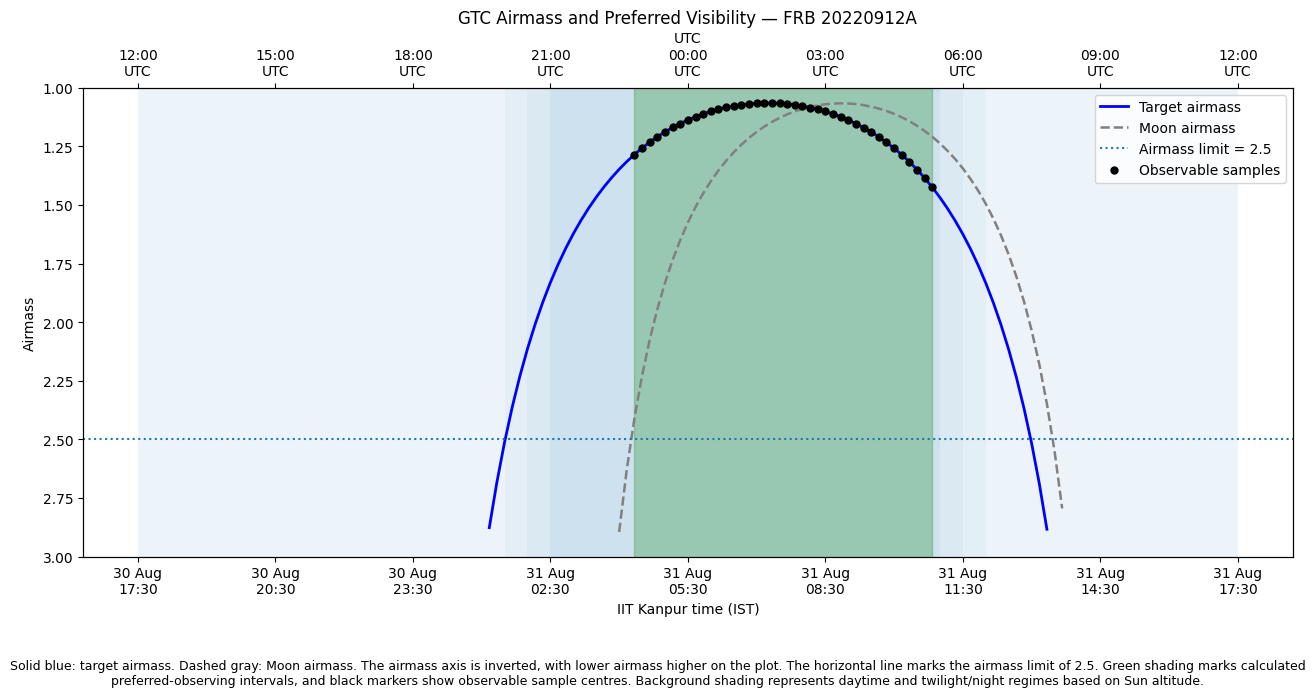

Figure saved to: assignment_outputs/frb_20220912a_gtc_airmass.png


In [33]:
#generating plot

# Target airmass
target_airmass = np.asarray(frb_altaz.secz, dtype=float)

# Keep target airmass between 1 and 3 for plotting
target_airmass_plot = target_airmass.copy()
target_airmass_plot[
    (~np.isfinite(target_airmass_plot))
    | (target_airmass_plot < 1)
    | (target_airmass_plot > 3)
] = np.nan

# Convert times to IST
times_ist = times.to_datetime(timezone=IITK_TIMEZONE)

# Output directory
output_dir = Path("assignment_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "frb_20220912a_gtc_airmass.png"


# Create figure

fig, ax = plt.subplots(figsize=(13, 7))

# Twilight / night background
sun_alt = sun_altitude.to_value(u.deg)

for i in range(len(times) - 1):

    if sun_alt[i] > -6:
        alpha = 0.08

    elif sun_alt[i] > -12:
        alpha = 0.12

    elif sun_alt[i] > -18:
        alpha = 0.16

    else:
        alpha = 0.22

    ax.axvspan(
        times_ist[i],
        times_ist[i + 1],
        alpha=alpha
    )

# Green shading for observable intervals
for start, end, t_start, t_end in windows:

    ax.axvspan(
        times_ist[start],
        times_ist[end],
        color="green",
        alpha=0.25
    )
    
# Target airmass: solid blue
ax.plot(
    times_ist,
    target_airmass_plot,
    color="blue",
    linestyle="-",
    linewidth=2,
    label="Target airmass"
)

# Moon airmass: dashed gray
ax.plot(
    times_ist,
    moon_airmass,
    color="gray",
    linestyle="--",
    linewidth=1.8,
    label="Moon airmass")

ax.axhline(
    2.5,
    linestyle=":",
    linewidth=1.5,
    label="Airmass limit = 2.5"
)

# Black markers for observable samples
observable_idx = np.flatnonzero(visibility_state)

ax.scatter(
    times_ist[observable_idx],
    target_airmass_plot[observable_idx],
    color="black",
    s=25,
    zorder=5,
    label="Observable samples"
)

# Airmass axis
ax.set_ylim(3, 1)

ax.set_ylabel("Airmass")
ax.set_xlabel("IIT Kanpur time (IST)")

# IIT Kanpur time axis
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b\n%H:%M",
        tz=IITK_TIMEZONE
    )
)

# UTC axis above
ax_utc = ax.twiny()

ax_utc.set_xlim(ax.get_xlim())

ax_utc.xaxis.set_major_locator(mdates.AutoDateLocator())

ax_utc.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%H:%M\nUTC",
        tz=mdates.UTC
    )
)

ax_utc.set_xlabel("UTC")

# Title
ax.set_title(
    "GTC Airmass and Preferred Visibility — FRB 20220912A"
)

# Legend
ax.legend(loc="upper right")


# Caption
caption = (
    "Solid blue: target airmass. Dashed gray: Moon airmass. "
    "The airmass axis is inverted, with lower airmass higher on the plot. "
    "The horizontal line marks the airmass limit of 2.5. "
    "Green shading marks calculated preferred-observing intervals, "
    "and black markers show observable sample centres. "
    "Background shading represents daytime and twilight/night regimes "
    "based on Sun altitude."
)

fig.text(
    0.5,
    0.01,
    caption,
    ha="center",
    va="bottom",
    fontsize=9,
    wrap=True
)


# Save figure
fig.tight_layout(rect=[0, 0.09, 1, 1])

fig.savefig(
    output_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", output_file)

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [34]:
# Full UTC day with the same 10-minute sampling
q_times = Time(
    "2026-09-01T00:00:00",
    scale="utc"
) + np.arange(145) * 10 * u.min


# Sun position and astronomical night

q_sun = get_sun(q_times)

q_altaz_frame = AltAz(
    obstime=q_times,
    location=gtc_location,
    pressure=0 * u.hPa
)

q_sun_altaz = q_sun.transform_to(q_altaz_frame)

q_sun_altitude = q_sun_altaz.alt


# Target position

q_target_altaz = frb_icrs.transform_to(q_altaz_frame)

q_target_altitude = q_target_altaz.alt

q_target_airmass = np.asarray(
    q_target_altaz.secz,
    dtype=float
)


# Visibility conditions

q_night = (q_sun_altitude <= -18 * u.deg)

q_above_horizon = (q_target_altitude > 0 * u.deg)

q_airmass_ok = (
    np.isfinite(q_target_airmass)
    & (q_target_airmass <= 2.5)
)

q_visibility = (
    q_night
    & q_above_horizon
    & q_airmass_ok
)


# Stitch consecutive visible samples

q_windows = stitch_windows(
    q_times,
    q_visibility
)


# Report intervals

total_duration = 0 * u.hour

for n, (start, end, t_start, t_end) in enumerate(
    q_windows,
    start=1
):

    duration = q_times[end] - q_times[start]

    total_duration += duration

    print(f"\nVisibility window {n}")
    print("-" * 50)

    print(
        "UTC:",
        f"{q_times[start].iso} --> {q_times[end].iso}"
    )

    print(
        "IIT Kanpur:",
        f"{q_times[start].to_datetime(timezone=IITK_TIMEZONE)}"
        f" --> "
        f"{q_times[end].to_datetime(timezone=IITK_TIMEZONE)}"
    )

    print(
        "Visible duration:",
        duration.to_value(u.hour),
        "hours"
    )


print("\nTotal visible duration:",
      total_duration.to_value(u.hour),
      "hours")


Visibility window 1
--------------------------------------------------
UTC: 2026-09-01 00:00:00.000 --> 2026-09-01 05:20:00.000
IIT Kanpur: 2026-09-01 05:30:00+05:30 --> 2026-09-01 10:50:00+05:30
Visible duration: 5.333333333333333 hours

Visibility window 2
--------------------------------------------------
UTC: 2026-09-01 21:00:00.000 --> 2026-09-02 00:00:00.000
IIT Kanpur: 2026-09-02 02:30:00+05:30 --> 2026-09-02 05:30:00+05:30
Visible duration: 3.0 hours

Total visible duration: 8.333333333333332 hours


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
